# Market Technical Indicators

## Overview

This notebook demonstrates the public functions in `market_technical_indicators`.

- Problem: dollar-bar price observations need breadth, momentum, overlap, and volatility features for downstream modeling.
- Approach: construct breadth, momentum, overlap, and volatility features from observed data.

## Observed Data

This cell defines the observed AAPL dollar-bar request and the technical-indicator output settings.

- `data_path` identifies `../../data/research_data/market/features/aapl_dollar_bar_2025-01-01_2025-12-31.parquet` as the source file.
- `end` contains the UTC timestamp of the final observation in each dollar bar.
- `start` contains the UTC timestamp of the first observation in each dollar bar.
- `symbol` identifies the instrument represented by the bar.
- `open` contains the first observed price in dollars.
- `high` contains the highest observed price in dollars.
- `low` contains the lowest observed price in dollars.
- `close` contains the final observed price in dollars.
- `volume` contains the total observed share volume.
- `dollar_value` contains the total derived dollar value.
- `ticks` contains the number of source trade observations.
- `buy_volume` contains the share volume assigned a positive direction.
- `sell_volume` contains the share volume assigned a negative direction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data_preprocessing.market_technical_indicators import (
    save_market_technical_indicators,
)

data_path = Path(
    "../../data/research_data/market/features/"
    "aapl_dollar_bar_2025-01-01_2025-12-31.parquet"
)

## Technical Indicator Feature Table

This cell calculates and saves the supported technical indicators for the observed dollar bars, then reports the model-ready feature fields.

- `window` sets the shared lookback to `14` dollar bars for indicators that accept a window.
- `plot_rows` limits each visualization to the most recent `2000` dollar bars while leaving the saved dataset complete.
- `output_path` is `None`, so the dataset is saved beside the source at `../../data/research_data/market/features/aapl_dollar_bar_technical_2025-01-01_2025-12-31.parquet`.
- `saved_path` identifies the parquet file written to the market feature directory.
- `start` identifies the UTC start timestamp retained from each source dollar bar.
- `end` identifies the UTC end timestamp retained from each source dollar bar.
- `symbol` identifies `AAPL` as the equity shared by all feature rows.
- `TRIN` is excluded because its cross-sectional market-breadth ratio is undefined for a single-symbol dataset.
- The remaining columns contain derived breadth, momentum, overlap, and volatility indicators; initial lookback rows can contain missing values.

In [2]:
window = 14
plot_rows = 2000
output_path = None

saved_path = save_market_technical_indicators(
    data_path=data_path,
    window=window,
    output_path=output_path,
)

technical_features = pd.read_parquet(saved_path)
print(saved_path)
display(technical_features.head())

2026-08-07 16:15:29.450 | INFO     | src.data_preprocessing.market_technical_indicators:save_market_technical_indicators:175 - Saved 156779 technical-indicator rows to ../../data/research_data/market/features/aapl_dollar_bar_technical_2025-01-01_2025-12-31.parquet.


../../data/research_data/market/features/aapl_dollar_bar_technical_2025-01-01_2025-12-31.parquet


,start,end,symbol,McClellan Oscillator,Advancers - Decliners,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator,New Highs - New Lows,Money Flow Index,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
0,2025-01-02 13:45:58.902948+00:00,2025-01-02 14:30:01.004279+00:00,AAPL,0.0000,0.00,0.0,-2037.819820,0.0000,0,NaN,...,NaN,NaN,1.110,1.1100,251.1300,248.9100,246.6900,NaN,NaN,NaN
1,2025-01-02 14:30:01.004306+00:00,2025-01-02 14:30:02.119118+00:00,AAPL,12.4325,248.65,-2059.0,-3626.191248,-505.3909,-1,NaN,...,NaN,NaN,0.350,0.7300,250.3353,248.8753,247.4153,NaN,NaN,NaN
2,2025-01-02 14:30:02.129080+00:00,2025-01-02 14:30:02.891073+00:00,AAPL,22.9971,248.59,-4072.0,-5639.191248,-1306.6971,-1,NaN,...,NaN,NaN,0.125,0.5283,249.8940,248.8373,247.7806,NaN,NaN,NaN
3,2025-01-02 14:30:02.929026+00:00,2025-01-02 14:30:04.394582+00:00,AAPL,31.9159,248.61,-2054.0,-6311.857915,-1729.7438,0,NaN,...,NaN,NaN,0.150,0.4338,249.6745,248.8070,247.9395,NaN,NaN,NaN
4,2025-01-02 14:30:04.394604+00:00,2025-01-02 14:30:05.084156+00:00,AAPL,39.3804,248.58,-4066.0,-6982.524582,-1958.9529,-1,NaN,...,NaN,NaN,0.060,0.3590,249.4947,248.7767,248.0587,NaN,NaN,NaN


## Breadth Indicators

Breadth indicators summarize how price and volume participation evolve across the observed dollar bars. This cell selects on-balance volume as the representative breadth feature from the saved table.

- `On-Balance Volume` accumulates share volume according to each closing-price change and remains unchanged when consecutive closes are equal.

In [3]:
breadth_feature = technical_features.set_index("end")[
    "On-Balance Volume"
]
display(breadth_feature.tail().to_frame())

,On-Balance Volume
end,
2025-12-30 20:59:29.259626+00:00,2567901.0
2025-12-30 20:59:37.473615+00:00,2566039.0
2025-12-30 20:59:44.068102+00:00,2564138.0
2025-12-30 20:59:48.950330+00:00,2562297.0
2025-12-30 20:59:56.362996+00:00,2564185.0


## Breadth Indicator Trends

This cell visualizes the most recent on-balance volume observations.

- The horizontal axis identifies the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The vertical axis reports cumulative share volume.

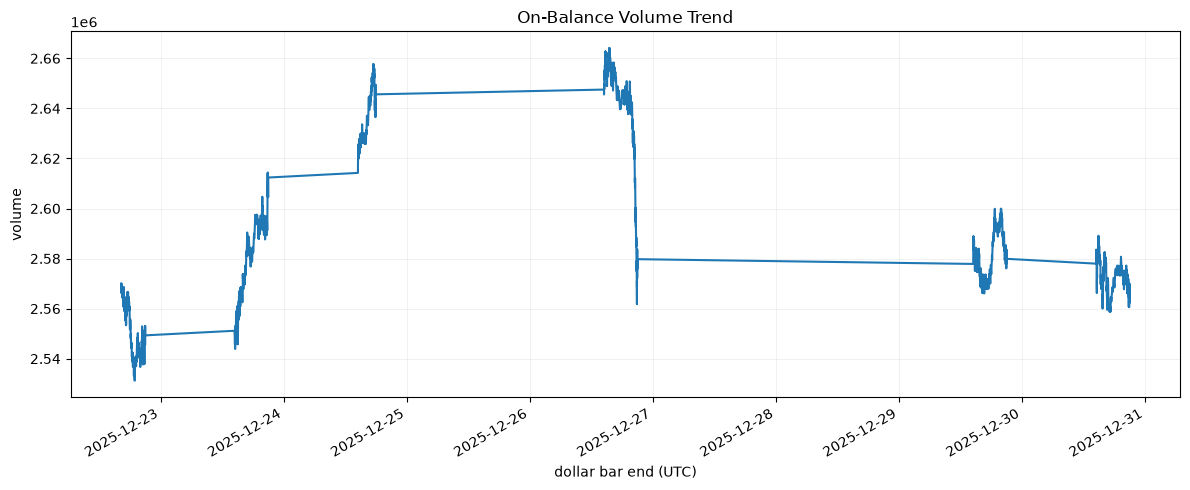

In [4]:
breadth_axis = breadth_feature.tail(plot_rows).plot(
    figsize=(12, 5),
    color="tab:blue",
)
breadth_axis.set_xlabel("dollar bar end (UTC)")
breadth_axis.set_ylabel("volume")
breadth_axis.set_title("On-Balance Volume Trend")
breadth_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Momentum Indicators

Momentum indicators describe the direction and strength of recent dollar-bar price changes. This cell selects the relative strength index as the representative momentum feature.

- `Relative Strength Index` measures recent upward price changes relative to downward changes on a scale from `0` to `100`.

In [5]:
momentum_feature = technical_features.set_index("end")[
    "Relative Strength Index"
]
display(momentum_feature.tail().to_frame())

,Relative Strength Index
end,
2025-12-30 20:59:29.259626+00:00,49.2063
2025-12-30 20:59:37.473615+00:00,30.2632
2025-12-30 20:59:44.068102+00:00,30.6667
2025-12-30 20:59:48.950330+00:00,26.9231
2025-12-30 20:59:56.362996+00:00,40.6977


## Momentum Indicator Trends

This cell visualizes the most recent relative strength index observations.

- The horizontal axis identifies the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The vertical axis reports the relative strength index from `0` to `100`, with `30` and `70` as common reference levels.

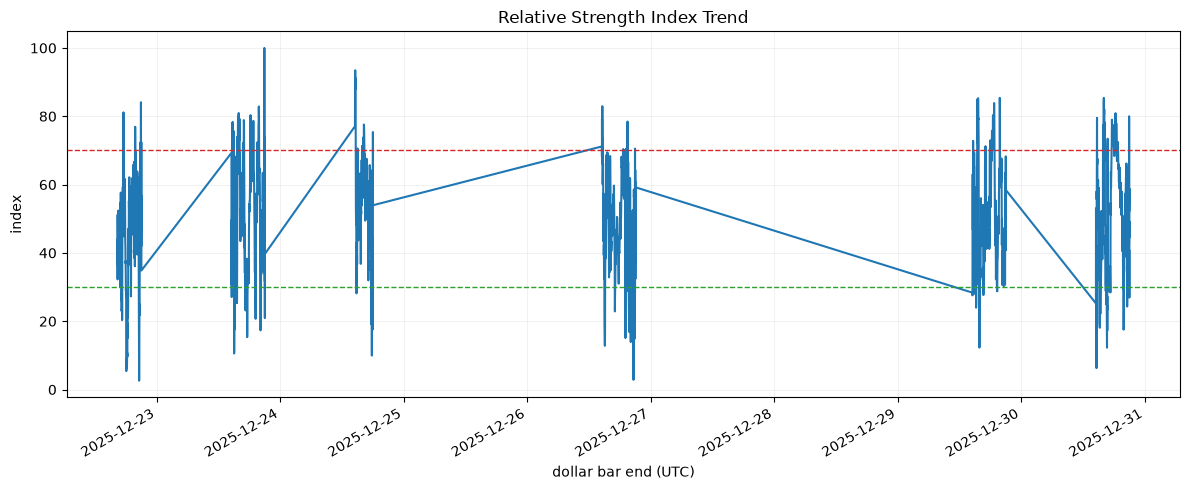

In [6]:
momentum_axis = momentum_feature.tail(plot_rows).plot(
    figsize=(12, 5),
    color="tab:blue",
)
momentum_axis.axhline(70, color="tab:red", linestyle="--", linewidth=1)
momentum_axis.axhline(30, color="tab:green", linestyle="--", linewidth=1)
momentum_axis.set_xlabel("dollar bar end (UTC)")
momentum_axis.set_ylabel("index")
momentum_axis.set_title("Relative Strength Index Trend")
momentum_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Overlap Indicators

Overlap indicators smooth or weight recent dollar-bar prices to expose the prevailing price level. This cell selects the exponential moving average as the representative overlap feature.

- `Exponential Moving Average (EMA)` reports a closing-price average in dollars that weights recent bars more heavily.

In [7]:
overlap_feature = technical_features.set_index("end")[
    "Exponential Moving Average (EMA)"
]
display(overlap_feature.tail().to_frame())

,Exponential Moving Average (EMA)
end,
2025-12-30 20:59:29.259626+00:00,273.1390
2025-12-30 20:59:37.473615+00:00,273.1231
2025-12-30 20:59:44.068102+00:00,273.1060
2025-12-30 20:59:48.950330+00:00,273.0879
2025-12-30 20:59:56.362996+00:00,273.0815


## Overlap Indicator Trends

This cell visualizes the most recent exponential moving average observations.

- The horizontal axis identifies the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The vertical axis reports the exponential moving average price in dollars.

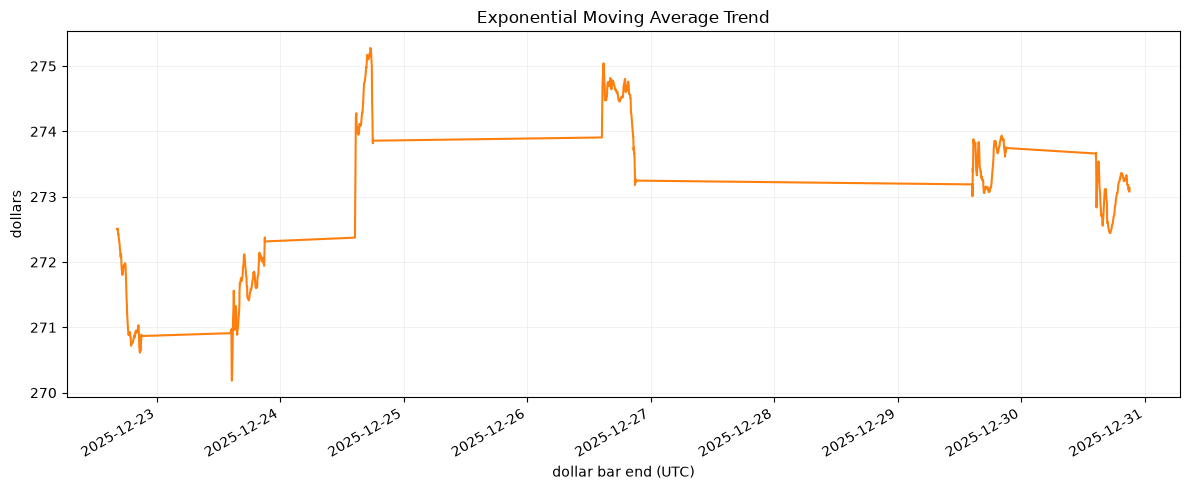

In [8]:
overlap_axis = overlap_feature.tail(plot_rows).plot(
    figsize=(12, 5),
    color="tab:orange",
)
overlap_axis.set_xlabel("dollar bar end (UTC)")
overlap_axis.set_ylabel("dollars")
overlap_axis.set_title("Exponential Moving Average Trend")
overlap_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Volatility Indicators

Volatility indicators describe the recent price envelope and range of the observed dollar bars. This cell selects average true range as the representative volatility feature.

- `Average True Range` reports the smoothed dollar range, including gaps between consecutive bars.

In [9]:
volatility_feature = technical_features.set_index("end")[
    "Average True Range"
]
display(volatility_feature.tail().to_frame())

,Average True Range
end,
2025-12-30 20:59:29.259626+00:00,0.0386
2025-12-30 20:59:37.473615+00:00,0.0439
2025-12-30 20:59:44.068102+00:00,0.0443
2025-12-30 20:59:48.950330+00:00,0.0461
2025-12-30 20:59:56.362996+00:00,0.0496


## Volatility Indicator Trends

This cell visualizes the most recent average true range observations.

- The horizontal axis identifies the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The vertical axis reports average true range in dollars as a positive range measure.

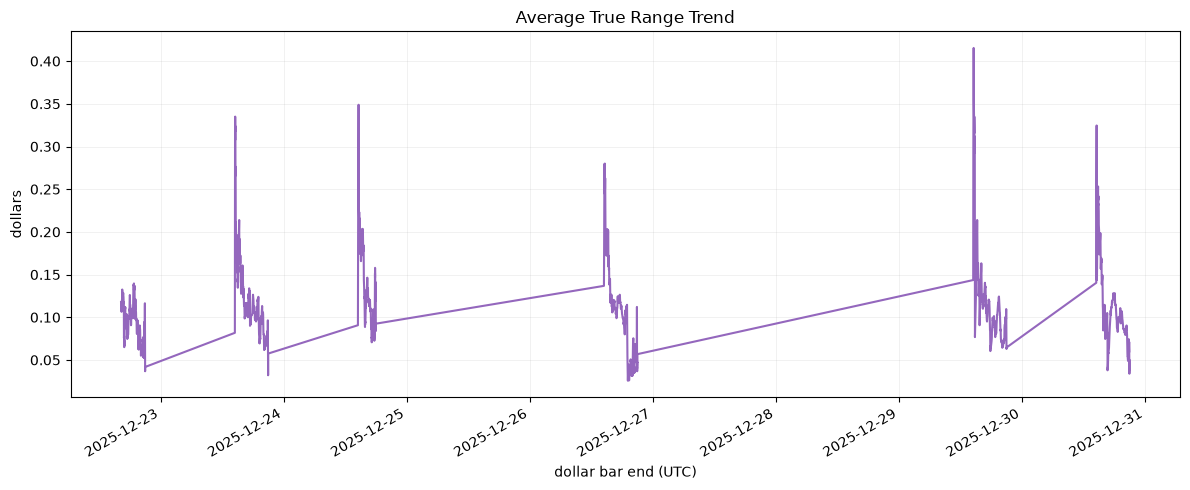

In [10]:
volatility_axis = volatility_feature.tail(plot_rows).plot(
    figsize=(12, 5),
    color="tab:purple",
)
volatility_axis.set_xlabel("dollar bar end (UTC)")
volatility_axis.set_ylabel("dollars")
volatility_axis.set_title("Average True Range Trend")
volatility_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()